In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "divar.csv"

In [3]:
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_24172\2144582446.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [4]:
df.shape

(1000000, 61)

In [8]:
needed_cols = [
    "price_value",
    "land_size",
    "building_size",
    "regular_person_capacity",
    "rooms_count",
    "location_latitude",
    "location_longitude",
]

In [9]:
df_q8 = df[needed_cols].copy()
df_q8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   price_value              568346 non-null  float64
 1   land_size                186396 non-null  float64
 2   building_size            980394 non-null  float64
 3   regular_person_capacity  29870 non-null   float64
 4   rooms_count              845899 non-null  object 
 5   location_latitude        655608 non-null  float64
 6   location_longitude       655608 non-null  float64
dtypes: float64(6), object(1)
memory usage: 53.4+ MB


In [10]:
df_q8["rooms_count"].dropna().value_counts().head(30)

rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [11]:
rooms_mapping = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df_q8["rooms_count"] = df_q8["rooms_count"].map(rooms_mapping)

In [12]:
df_q8["rooms_count"].dropna().value_counts().head(30)

rooms_count
2.0    404050
1.0    192083
3.0    138633
0.0     75898
4.0     21371
5.0     13864
Name: count, dtype: int64

In [13]:
df_q8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   price_value              568346 non-null  float64
 1   land_size                186396 non-null  float64
 2   building_size            980394 non-null  float64
 3   regular_person_capacity  29870 non-null   float64
 4   rooms_count              845899 non-null  float64
 5   location_latitude        655608 non-null  float64
 6   location_longitude       655608 non-null  float64
dtypes: float64(7)
memory usage: 53.4 MB


In [14]:
df_q8.isnull().sum()/df.shape[0]*100

price_value                43.1654
land_size                  81.3604
building_size               1.9606
regular_person_capacity    97.0130
rooms_count                15.4101
location_latitude          34.4392
location_longitude         34.4392
dtype: float64

The following columns cannot have negative values, so we perform a minor data cleaning step.

In [15]:
df_q8_clean = df_q8.copy()

df_q8_clean = df_q8_clean[
    (df_q8_clean["price_value"].isna()) |
    (df_q8_clean["price_value"] > 0)
]

df_q8_clean = df_q8_clean[
    (df_q8_clean["land_size"].isna()) |
    (df_q8_clean["land_size"] > 0)
]

df_q8_clean = df_q8_clean[
    (df_q8_clean["building_size"].isna()) |
    (df_q8_clean["building_size"] > 0)
]

In [16]:
corr_matrix = df_q8_clean.corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

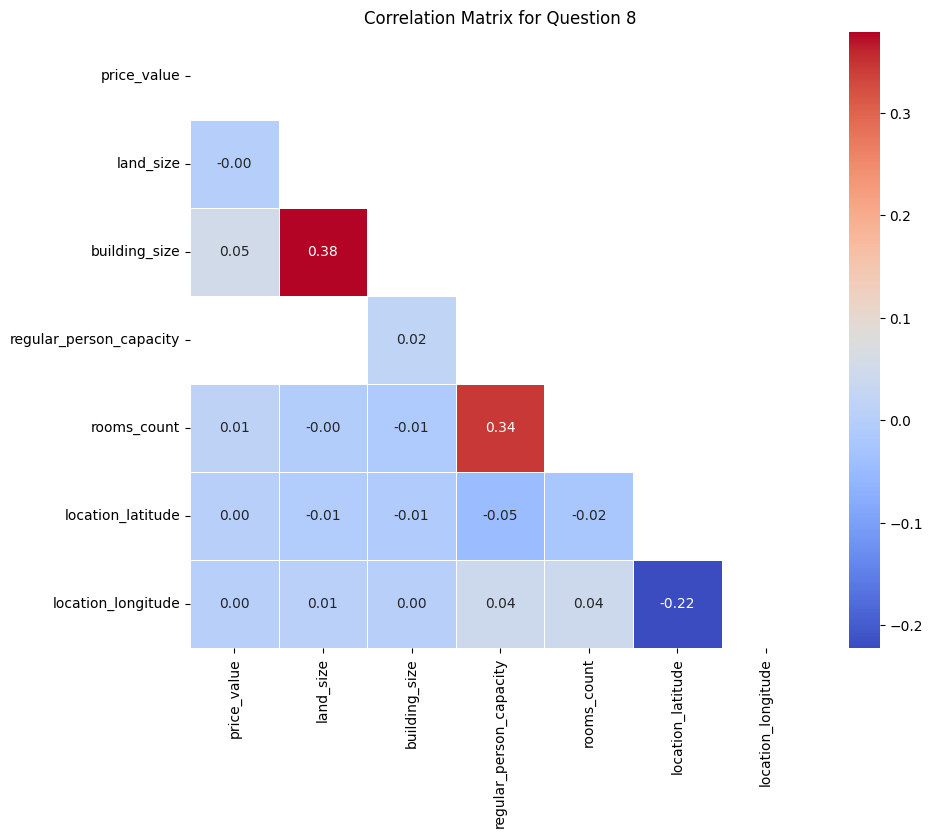

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix for Question 8")
plt.show()

Some cells in the correlation matrix are empty because there are no rows where both corresponding columns have non-null values.

In [18]:
valid_counts = df_q8.notna().astype(int).T.dot(
    df_q8.notna().astype(int)
)

valid_counts

,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_latitude,location_longitude
price_value,568346,121736,567064,0,456888,372119,372119
land_size,121736,186396,186396,0,186396,113566,113566
building_size,567064,186396,980394,29870,845899,644526,644526
regular_person_capacity,0,0,29870,29870,29870,19456,19456
rooms_count,456888,186396,845899,29870,845899,559319,559319
location_latitude,372119,113566,644526,19456,559319,655608,655608
location_longitude,372119,113566,644526,19456,559319,655608,655608


The correlation heatmap shows that most numerical features have weak relationships with each other. Most correlation values are close to zero, so there is no strong linear relationship between many of the columns.

The highest positive correlations are between land_size and building_size with a value of 0.38, and between regular_person_capacity and rooms_count with a value of 0.34. These results make sense because larger properties may have larger buildings, and houses with more rooms can usually have more capacity.

There is also a weak negative correlation between location_latitude and location_longitude, with a value of -0.22. This does not mean that latitude causes longitude to change. It mainly shows the geographical distribution of the records across Iran.